<a href="https://colab.research.google.com/github/shreyansdeshp/LiDAR/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


In [ ]:

from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv('Algerian_forest_fires_dataset_CLEANED.csv')

print(df.head())
print(df.info())
print(df.describe())


Saving Algerian_forest_fires_dataset_CLEANED.csv to Algerian_forest_fires_dataset_CLEANED (2).csv
   Unnamed: 0  day  month  year  Temperature  RH  Ws  Rain  FFMC  DMC    DC  \
0           1    1      6  2012           29  57  18   0.0  65.7  3.4   7.6   
1           2    2      6  2012           29  61  13   1.3  64.4  4.1   7.6   
2           3    3      6  2012           26  82  22  13.1  47.1  2.5   7.1   
3           4    4      6  2012           25  89  13   2.5  28.6  1.3   6.9   
4           5    5      6  2012           27  77  16   0.0  64.8  3.0  14.2   

   ISI  BUI  FWI  Classes  Region  
0  1.3  3.4  0.5  notfire  Bejaia  
1  1.0  3.9  0.4  notfire  Bejaia  
2  0.3  2.7  0.1  notfire  Bejaia  
3  0.0  1.7  0.0  notfire  Bejaia  
4  1.2  3.9  0.5  notfire  Bejaia  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   243 

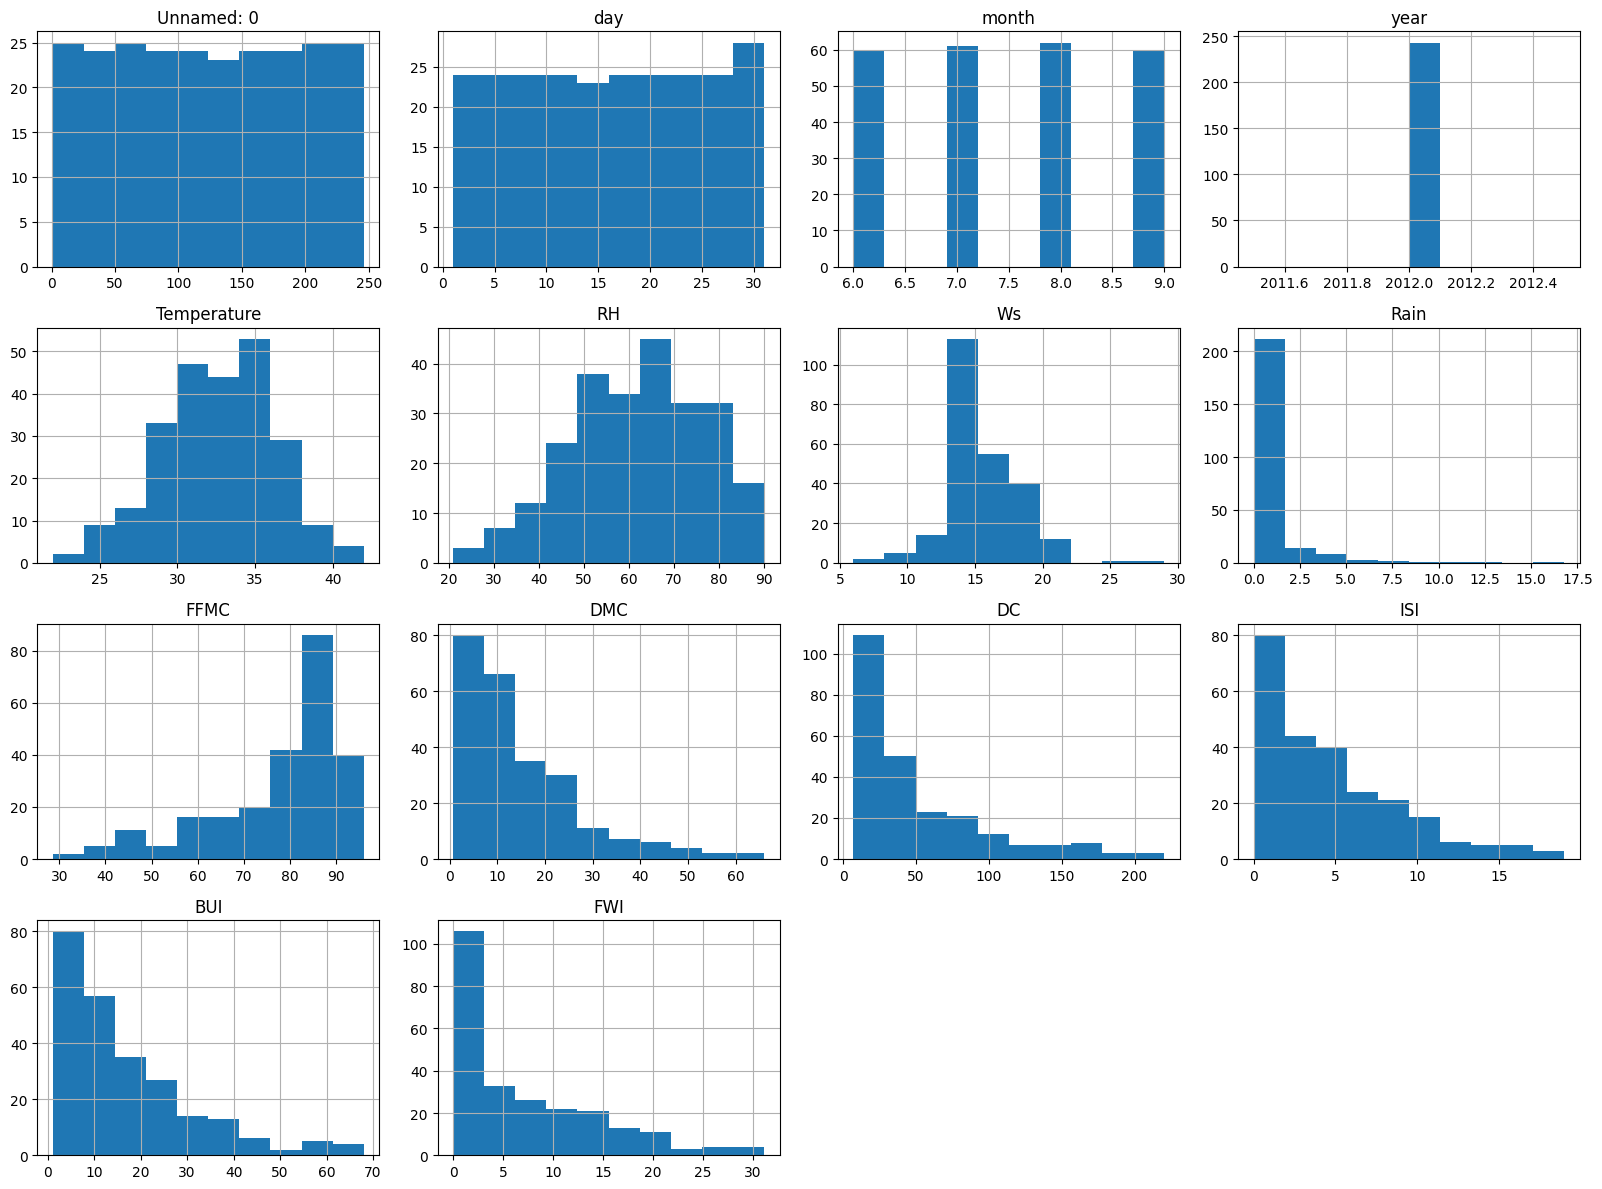

In [ ]:
df["Classes"].value_counts()
df.hist(figsize=(16,12))
plt.tight_layout()
plt.show()

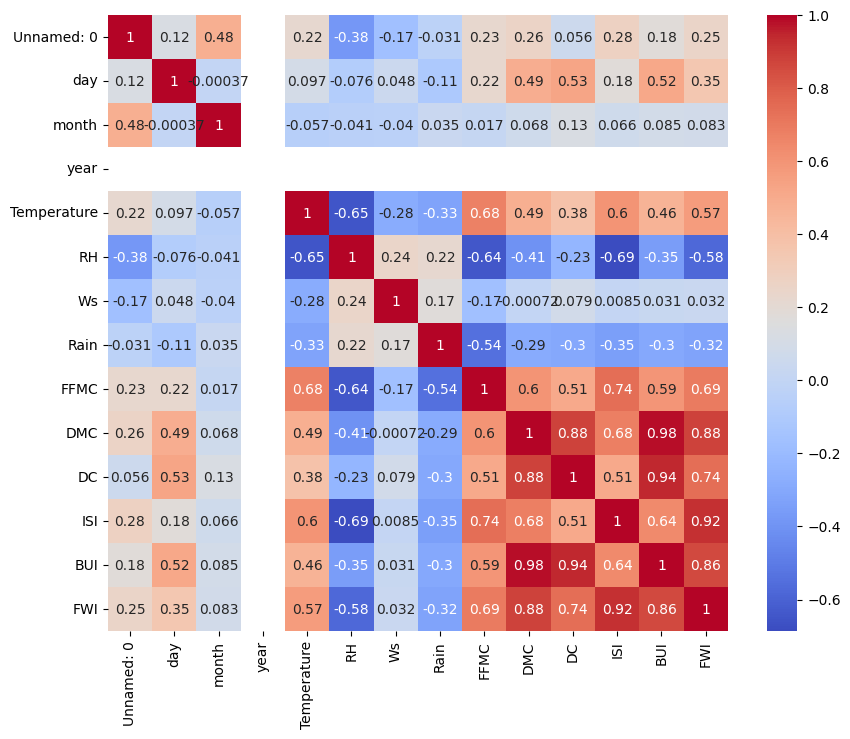

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

skewness = df[numeric_cols].skew().sort_values(ascending=False)

print(skewness)

Rain           4.568630
DMC            1.522983
DC             1.473460
BUI            1.452745
FWI            1.147593
ISI            1.140243
Ws             0.555586
Unnamed: 0     0.006740
day            0.000365
year           0.000000
month         -0.005207
Temperature   -0.191327
RH            -0.242790
FFMC          -1.320130
dtype: float64


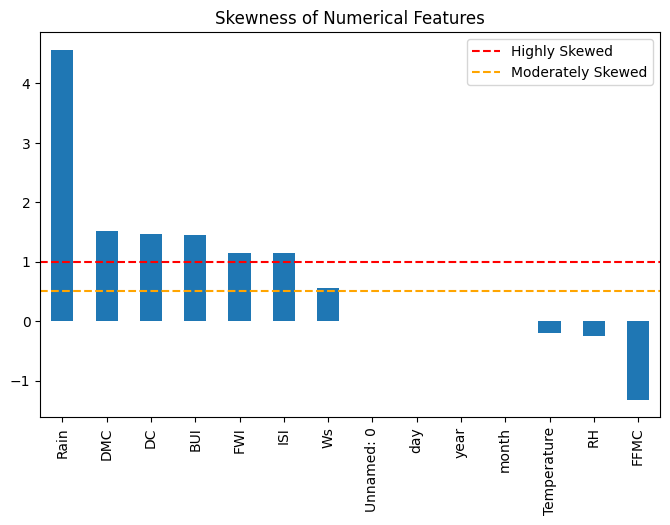

In [ ]:
plt.figure(figsize=(8,5))
skewness.plot(kind="bar")
plt.axhline(1, color="red", linestyle="--", label="Highly Skewed")
plt.axhline(0.5, color="orange", linestyle="--", label="Moderately Skewed")
plt.legend()
plt.title("Skewness of Numerical Features")
plt.show()

In [ ]:
log_features = ["Rain", "DMC", "DC", "ISI", "BUI", "FWI"]

df[log_features] = np.log1p(df[log_features])

In [ ]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness)

Rain           2.207224
Ws             0.555586
DC             0.087862
Unnamed: 0     0.006740
day            0.000365
year           0.000000
month         -0.005207
FWI           -0.022792
ISI           -0.065109
BUI           -0.089787
DMC           -0.184266
Temperature   -0.191327
RH            -0.242790
FFMC          -1.320130
dtype: float64


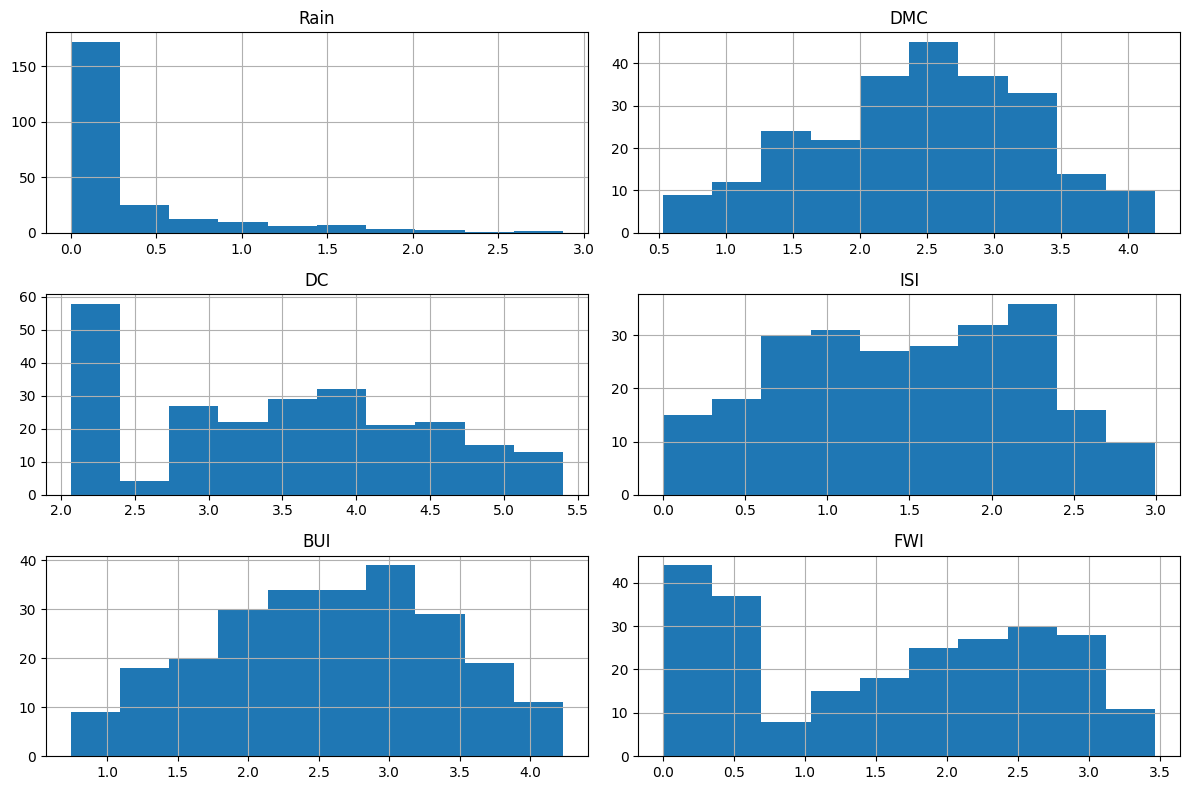

In [ ]:
df[log_features].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:
before_skew = {
    "Rain": 4.568630,
    "DMC": 1.522983,
    "DC": 1.473460,
    "BUI": 1.452745,
    "FWI": 1.147593,
    "ISI": 1.140243
}

after_skew = df[log_features].skew()

comparison = pd.DataFrame({
    "Before Log": before_skew,
    "After Log": after_skew
})

comparison

,Before Log,After Log
BUI,1.452745,-0.089787
DC,1.473460,0.087862
DMC,1.522983,-0.184266
FWI,1.147593,-0.022792
ISI,1.140243,-0.065109
Rain,4.568630,2.207224


In [ ]:
df = pd.read_csv("Algerian_forest_fires_dataset_CLEANED.csv")
df.drop(columns=["Unnamed: 0", "year"], inplace=True)
df.head()

,day,month,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,notfire,Bejaia
1,2,6,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,notfire,Bejaia
2,3,6,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,notfire,Bejaia
3,4,6,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,notfire,Bejaia
4,5,6,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,notfire,Bejaia


In [ ]:
from sklearn.preprocessing import LabelEncoder

class_encoder = LabelEncoder()
region_encoder = LabelEncoder()

df["Classes"] = class_encoder.fit_transform(df["Classes"])
df["Region"] = region_encoder.fit_transform(df["Region"])
df.head()

,day,month,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1,0
1,2,6,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1,0
2,3,6,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,0
3,4,6,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1,0
4,5,6,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1,0


In [ ]:
X = df.drop("Classes", axis=1)
y = df["Classes"]
print(X.shape)
print(y.shape)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

df["Region"].unique()

(243, 13)
(243,)
(170, 13)
(36, 13)
(37, 13)
Classes
0    96
1    74
Name: count, dtype: int64
Classes
0    20
1    16
Name: count, dtype: int64
Classes
0    21
1    16
Name: count, dtype: int64


array([0, 1])

In [ ]:
log_features = ["Rain", "DMC", "DC", "ISI", "BUI", "FWI"]

for dataset in [X_train, X_val, X_test]:
    dataset.loc[:, log_features] = np.log1p(dataset[log_features])
    from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)
print(np.mean(X_train_scaled, axis=0))

print(np.std(X_train_scaled, axis=0))

[-9.40424209e-17 -4.44089210e-17 -6.58296946e-16 -1.70451888e-16
  8.09809736e-17 -4.17966315e-17 -3.91843420e-16 -7.31441052e-17
  5.32907052e-16  5.22457894e-17  1.25389895e-16 -2.08983158e-16
 -1.04491579e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
y_val_tensor = torch.FloatTensor(y_val.values).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

In [ ]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)
for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([32, 13])
torch.Size([32, 1])


In [ ]:
class ForestFireNN(nn.Module):

    def __init__(self):
        super(ForestFireNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(13, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)
model = ForestFireNN()
print(model)

total_params = sum(p.numel() for p in model.parameters())

print("Total Trainable Parameters:", total_params)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Validation Loss: {val_loss:.4f}")

ForestFireNN(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total Trainable Parameters: 3201
Epoch [1/50] Train Loss: 0.6500 Validation Loss: 0.6525
Epoch [2/50] Train Loss: 0.5275 Validation Loss: 0.5828
Epoch [3/50] Train Loss: 0.4758 Validation Loss: 0.5152
Epoch [4/50] Train Loss: 0.4359 Validation Loss: 0.4555
Epoch [5/50] Train Loss: 0.3990 Validation Loss: 0.4083
Epoch [6/50] Train Loss: 0.3809 Validation Loss: 0.3812
Epoch [7/50] Train Loss: 0.3353 Validation Loss: 0.3603
Epoch [8/50] Train Loss: 0.3303 Validation Loss: 0.3418
Epoch [

In [ ]:
import torch
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

model.eval()

probs = []
labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits = model(X_batch)
        probability = torch.sigmoid(logits)

        probs.extend(probability.squeeze().cpu().numpy())
        labels.extend(y_batch.squeeze().cpu().numpy())

probs = np.array(probs)
labels = np.array(labels)

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for t in thresholds:

    preds = (probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()

    results.append([
        round(t,2),
        accuracy_score(labels, preds),
        precision_score(labels, preds, zero_division=0),
        recall_score(labels, preds, zero_division=0),
        f1_score(labels, preds, zero_division=0),
        fp,
        fn
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "FP",
        "FN"
    ]
)

print(results)

    Threshold  Accuracy  Precision  Recall        F1  FP  FN
0        0.10  0.916667   0.842105  1.0000  0.914286   3   0
1        0.15  0.916667   0.842105  1.0000  0.914286   3   0
2        0.20  0.916667   0.842105  1.0000  0.914286   3   0
3        0.25  0.972222   0.941176  1.0000  0.969697   1   0
4        0.30  0.972222   0.941176  1.0000  0.969697   1   0
5        0.35  0.972222   0.941176  1.0000  0.969697   1   0
6        0.40  0.972222   0.941176  1.0000  0.969697   1   0
7        0.45  0.972222   0.941176  1.0000  0.969697   1   0
8        0.50  0.972222   0.941176  1.0000  0.969697   1   0
9        0.55  0.972222   0.941176  1.0000  0.969697   1   0
10       0.60  0.972222   0.941176  1.0000  0.969697   1   0
11       0.65  0.972222   0.941176  1.0000  0.969697   1   0
12       0.70  0.972222   0.941176  1.0000  0.969697   1   0
13       0.75  0.972222   0.941176  1.0000  0.969697   1   0
14       0.80  0.972222   0.941176  1.0000  0.969697   1   0
15       0.85  0.972222 

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

model.eval()

with torch.no_grad():

    outputs = model(X_test_tensor)

    probabilities = torch.sigmoid(outputs)

    predictions = (probabilities >= 0.65).float()

y_true = y_test_tensor.numpy()

y_pred = predictions.numpy()

accuracy = accuracy_score(y_true, y_pred)

conf_matrix = confusion_matrix(y_true, y_pred)

roc_auc = roc_auc_score(y_true, probabilities.numpy())

print(f"Test Accuracy : {accuracy:.4f}")

print(f"ROC-AUC Score : {roc_auc:.4f}")

print("\nConfusion Matrix\n")

print(conf_matrix)

print("\nClassification Report\n")

print(classification_report(y_true, y_pred))

Test Accuracy : 0.9459
ROC-AUC Score : 0.9911

Confusion Matrix

[[20  1]
 [ 1 15]]

Classification Report

              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95        21
         1.0       0.94      0.94      0.94        16

    accuracy                           0.95        37
   macro avg       0.94      0.94      0.94        37
weighted avg       0.95      0.95      0.95        37



In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score
)

model.eval()

with torch.no_grad():

    logits = model(X_test_tensor)

    probabilities = torch.sigmoid(logits)

    predictions = (probabilities >= 0.35).float()

y_true = y_test_tensor.cpu().numpy()
y_pred = predictions.cpu().numpy()
y_prob = probabilities.cpu().numpy()

print("Accuracy :", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

print("ROC-AUC :", roc_auc_score(y_true, y_prob))

Accuracy : 0.9459459459459459

Confusion Matrix

[[20  1]
 [ 1 15]]

Classification Report

              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95        21
         1.0       0.94      0.94      0.94        16

    accuracy                           0.95        37
   macro avg       0.94      0.94      0.94        37
weighted avg       0.95      0.95      0.95        37

ROC-AUC : 0.9910714285714286


<Figure size 600x600 with 0 Axes>

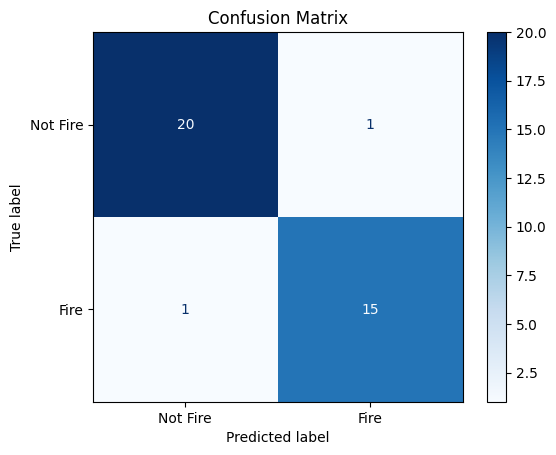

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fire", "Fire"]
)

plt.figure(figsize=(6,6))

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

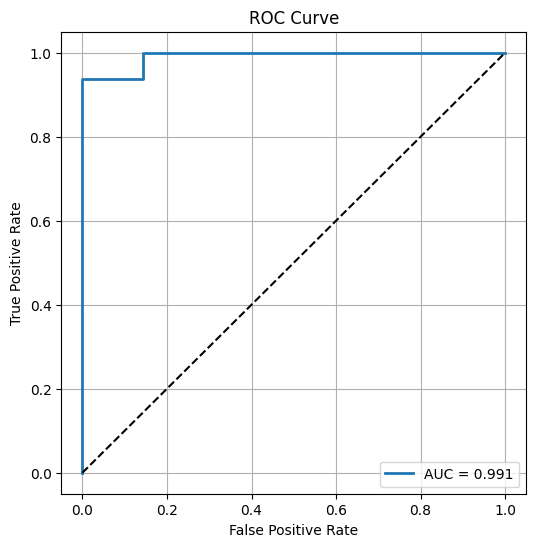

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, linewidth=2,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
results = pd.DataFrame({
    "Probability": probs,
    "Actual": labels
})

print(results.sort_values("Probability"))

    Probability  Actual
2      0.003129     0.0
32     0.004764     0.0
29     0.005127     0.0
5      0.007631     0.0
1      0.008540     0.0
35     0.010395     0.0
20     0.014817     0.0
4      0.016029     0.0
12     0.016069     0.0
9      0.016431     0.0
16     0.017405     0.0
28     0.031599     0.0
11     0.034681     0.0
10     0.035167     0.0
14     0.043921     0.0
30     0.055536     0.0
26     0.082095     0.0
0      0.204859     0.0
27     0.241687     0.0
33     0.833276     1.0
15     0.839109     0.0
23     0.941666     1.0
31     0.950696     1.0
17     0.970737     1.0
3      0.971600     1.0
24     0.974514     1.0
8      0.976645     1.0
21     0.978572     1.0
13     0.979897     1.0
22     0.984500     1.0
34     0.987278     1.0
18     0.988346     1.0
6      0.992501     1.0
19     0.993521     1.0
7      0.993618     1.0
25     0.996301     1.0


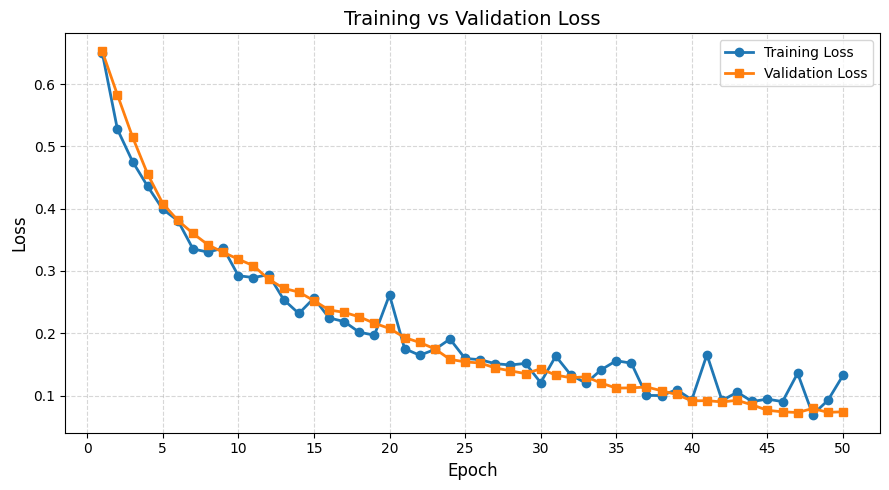

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

epochs = range(1, len(train_losses) + 1)

plt.plot(epochs,
         train_losses,
         marker='o',
         linewidth=2,
         label='Training Loss')

plt.plot(epochs,
         val_losses,
         marker='s',
         linewidth=2,
         label='Validation Loss')

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Loss", fontsize=14)

plt.xticks(range(0, len(train_losses)+1, 5))
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()
plt.show()